In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
import matplotlib.cm as cm
import duckdb
from pathlib import Path
import mpl_scatter_density

: 

In [13]:
# angmomdir = Path("/Volumes/newpassport/tables/spheres")
# made_spheres = [f.stem for f in angmomdir.glob("*.parquet")]
clu_params = pd.read_csv("../data/clu_params.csv")

In [3]:
10 / np.sqrt(2)

np.float64(7.071067811865475)

In [14]:
clu_params = clu_params.loc[clu_params.name == name]
r_clu = clu_params[["x", "y", "z"]].to_numpy().flatten()

In [8]:
name = "Alessi_3"
dvtlim = 2

clu_params = clu_params.loc[clu_params.name == name]
r_clu = clu_params[["x", "y", "z"]].to_numpy().flatten()

df = duckdb.query(f"""
    SELECT * FROM '/Volumes/newpassport/spheres/{name}.parquet'
    WHERE parallax_over_error > 10
    AND delta_vT < 15
""").df()

print("N: ", len(df))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

N:  290576


In [37]:
dvtlim = 2

In [16]:
halfedge = 195 / np.sqrt(3)

cube_cond = (
    df.X.between(r_clu[0] - halfedge, r_clu[0] + halfedge)
    & df.Y.between(r_clu[1] - halfedge, r_clu[1] + halfedge)
    & df.Z.between(r_clu[2] - halfedge, r_clu[2] + halfedge)
)

foo = df.loc[cube_cond]

/Users/sharifi/Documents/escapees/.venv/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/sharifi/Documents/escapees/.venv/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill

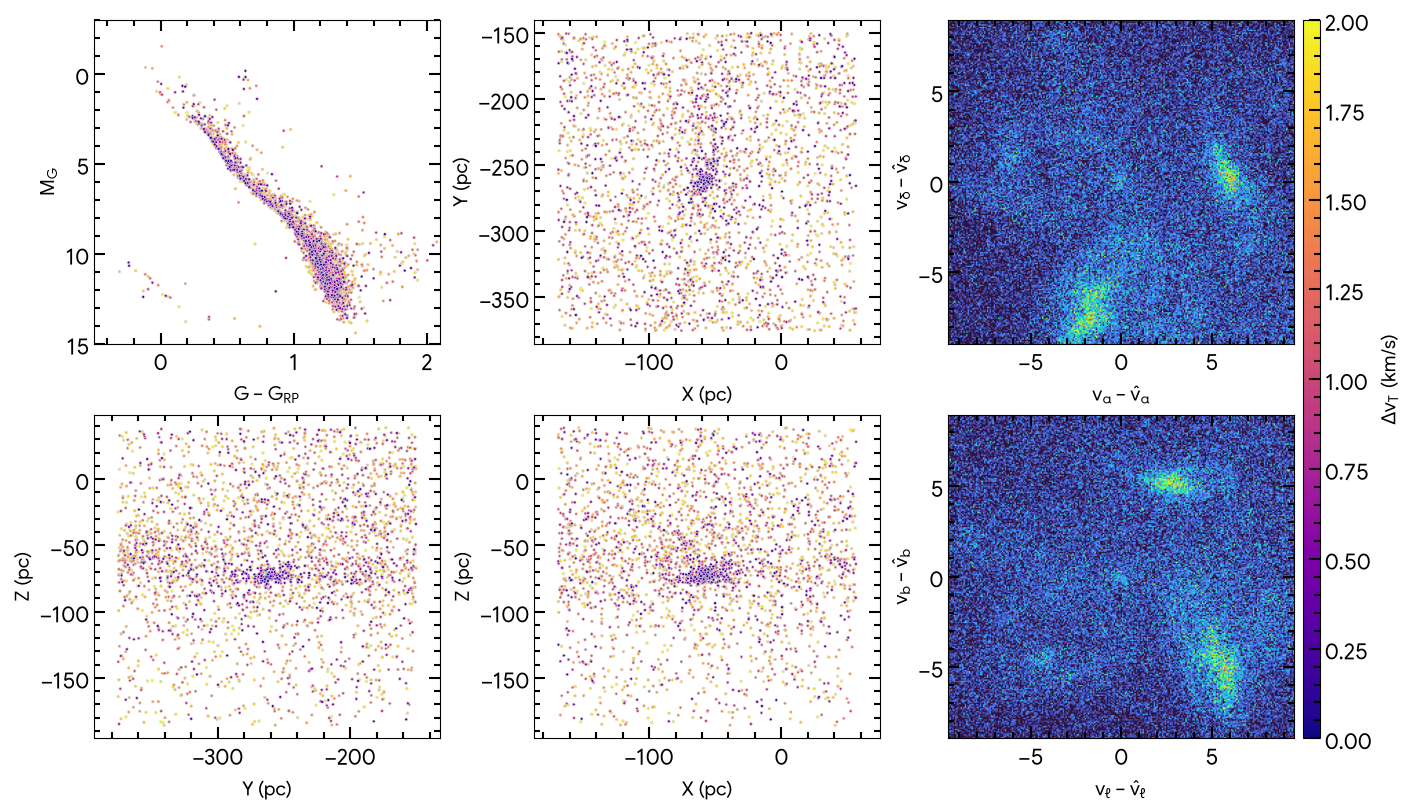

In [38]:
fig = plt.figure(
    figsize=(14, 8),
    constrained_layout=True,
)
gs = fig.add_gridspec(2, 4, width_ratios=[1] * 3 + [0.05])  # last column for colorbar
axes = np.empty((2, 3), dtype=object)
for i in range(2):
    for j in range(3):
        axes[i, j] = fig.add_subplot(gs[i, j], projection="scatter_density")

cmap_dvt = cm.plasma
cax = fig.add_subplot(gs[:, -1])
norm_dvt = Normalize(0, dvtlim)
mappable = cm.ScalarMappable(norm=norm_dvt, cmap=cmap_dvt)
cbar = fig.colorbar(mappable, cax=cax)
cbar.set_label(r"$\Delta v_T\ (km/s)$", fontsize=14)

ix = np.flip(np.argsort(foo.delta_vT))
foo = foo.iloc[ix]

xys = (
    (
        foo.g_rp.loc[foo.delta_vT < dvtlim],
        foo.phot_g_mean_mag.loc[foo.delta_vT < dvtlim]
        + 5 * np.log10(foo.parallax.loc[foo.delta_vT < dvtlim] / 100),
    ),
    (foo.X.loc[foo.delta_vT < dvtlim], foo.Y.loc[foo.delta_vT < dvtlim]),
    (foo.delta_vra, foo.delta_vdec),
    (foo.Y.loc[foo.delta_vT < dvtlim], foo.Z.loc[foo.delta_vT < dvtlim]),
    (foo.X.loc[foo.delta_vT < dvtlim], foo.Z.loc[foo.delta_vT < dvtlim]),
    (foo.delta_vl, foo.delta_vb),
)
labels = (
    (r"$G-G_{RP}$", r"$M_G$"),
    ("X (pc)", "Y (pc)"),
    (r"$v_\alpha-\hat{v}_\alpha$", r"$v_\delta-\hat{v}_\delta$"),
    ("Y (pc)", "Z (pc)"),
    ("X (pc)", "Z (pc)"),
    (r"$v_\ell - \hat{v}_\ell$", r"$v_b - \hat{v}_b$"),
)


for i, (xy, label) in enumerate(zip(xys, labels)):
    ax = axes[i // 3, i % 3]
    ax.set_xlabel(label[0], fontsize=14)
    ax.set_ylabel(label[1], fontsize=14)

    if i % 3 != 2:
        ax.scatter(
            xy[0],
            xy[1],
            c=foo.delta_vT.loc[foo.delta_vT < dvtlim],
            cmap=cmap_dvt,
            norm=norm_dvt,
            # dpi=100,
            s=4,
            edgecolors="gainsboro",
            linewidth=0.4,
        )

    if i == 0:
        ax.set_xlim(-0.5, 2.1)
        ax.set_ylim(-3, 15)
        ax.invert_yaxis()

    if i % 3 == 2:
        ax.scatter_density(xy[0], xy[1], cmap="turbo")
        # ax.hexbin(
        #     xy[0],
        #     xy[1],
        #     gridsize=200,
        #     cmap="Grays",
        #     # bins="log",
        #     mincnt=1,
        #     extent=[-10, 10] + list(np.sort([-10, 10])),
        # )
        ax.set_xlim(-10, 10)
        ax.set_ylim(-10, 10)

    if i != 0:
        ax.set_aspect("equal", adjustable="datalim")


plt.savefig(
    f"/Volumes/newpassport/plots/{name}.png",
    dpi=400,
    bbox_inches="tight",
)

plt.show()

In [ ]:
import pandas as pd

: 

In [ ]:
foo = pd.read_csv("/Users/sharifi/Downloads/emma_hr24_mem.csv")